In [1]:
import nsbi_common_utils
import pandas as pd
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt

In [2]:
BASE_PATH = "./data_nsbi_tutorial/"

In [3]:
nodes = [0, 5, 10]

In [4]:
signals = {
    f"signal_{n:g}": pd.read_parquet(f"{BASE_PATH}/signal_{n:g}.parquet") for n in nodes
}
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

In [5]:
training_features = ["x1", "x2", "x3", "x4", "x5"]

In [6]:
# numerator_hypothesis = pd.concat([signals["signal_0"], signals["signal_5"], signals["signal_10"]], ignore_index=True).astype('float32').copy()
numerator_hypothesis = signals["signal_10"].astype('float32').copy()
denominator_hypothesis = pd.concat([background, signals["signal_0"]], ignore_index=True).astype('float32').copy()

In [7]:
numerator_hypothesis.shape

(100000, 8)

In [8]:
numerator_hypothesis["weights"] = numerator_hypothesis['weight']
numerator_hypothesis["weights_normed"] = numerator_hypothesis['weight'] / numerator_hypothesis['weight'].sum()
numerator_hypothesis["train_labels"] = 1.0

denominator_hypothesis["weights"] = denominator_hypothesis['weight']
denominator_hypothesis["weights_normed"] = denominator_hypothesis['weight'] / denominator_hypothesis['weight'].sum()
denominator_hypothesis["train_labels"] = 0.0

In [9]:
training_dataframe = pd.concat([numerator_hypothesis, denominator_hypothesis], ignore_index=True)

In [ ]:
from nsbi_common_utils.training import density_ratio_trainer

trainer = density_ratio_trainer(
    dataset=training_dataframe,
    weights=training_dataframe["weights_normed"],
    training_labels=training_dataframe["train_labels"],
    features=training_features,
    features_scaling=training_features,
    sample_name=["signal_0", "reference"],
    output_name="sig/bkg",
    path_to_figures="plots_sig10vsRef/",
    path_to_models="models_sig10vsRef/",
)

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:10: FutureWarning: ``set_style`` is deprecated: Naming convention is changing to match mpl. Use ``mplhep.style.use()``.
  hep.set_style("ATLAS")


In [11]:
trainer.train(
    hidden_layers=3,
    neurons=1024,
    number_of_epochs=30,
    batch_size=1024,
    learning_rate=1e-3,
    scalerType="MinMax",
    ensemble_index=0,
    verbose=1,
    holdout_split=0.25, # validation
    validation_split=0.2,
    callback_patience=10,
    num_workers=4,
    load_trained_models=False,
    calibration=True,
    type_of_calibration = "histogram",
    recalibrate_output=True,
    num_bins_cal = 50
)

2026-05-14 14:21:46 | INFO | Training Logs | Sum of weights of class 0: 0.7499481040649147
2026-05-14 14:21:46 | INFO | Training Logs | Sum of weights of class 1: 0.7499999128413037
2026-05-14 14:21:46 | INFO | Training Logs | Using swish activation function
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [lit

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  2.1 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch    0 | lr = 1.000e-03 | val_loss = 0.693950 | 


...

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


<Figure size 800x600 with 0 Axes>

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:66: RuntimeWarning: invalid value encountered in divide
  hist_ratio = hist_num / (hist_den + hist_num)
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:68: RuntimeWarning: invalid value encountered in divide
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:69: RuntimeWarning: invalid value encountered in divide
  np.sqrt((hist_num_err / (hist_num)**2) + (hist_den_err / (hist_den)**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:78: RuntimeWarning: invalid value encountered in divide
  hist_ratio_holdout = hist_num_holdout / (hist_den_holdout + hist_num_holdout)
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:80: RuntimeWarning: invalid value encountered in divide
  hist_ratio_holdout**2 * np.abs(hist_den_ho

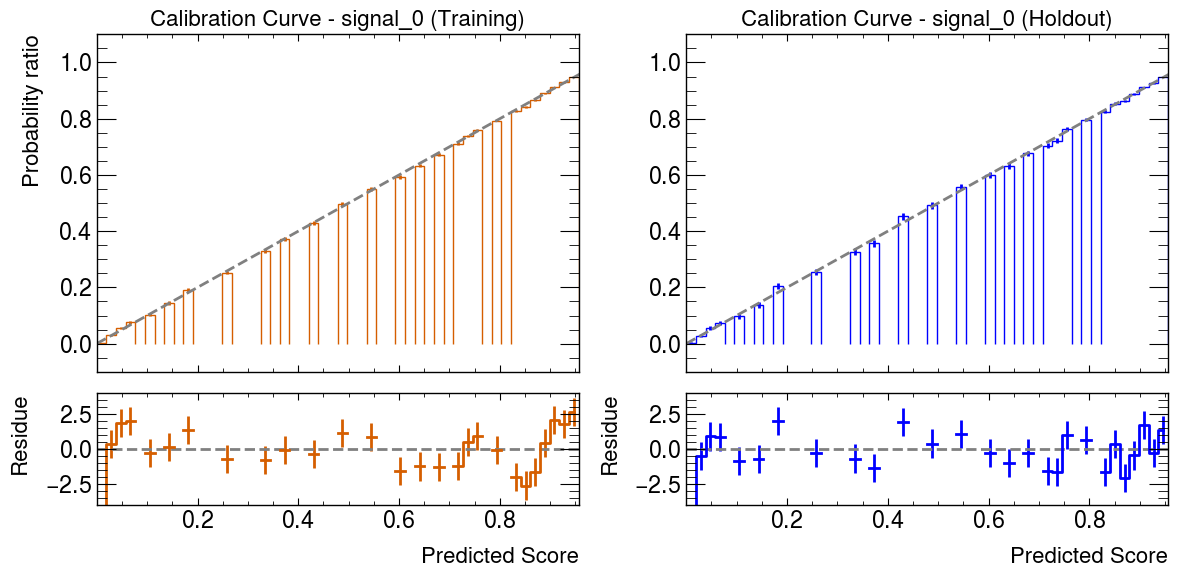

<Figure size 800x600 with 0 Axes>

In [12]:
trainer.make_calib_plots(observable='score', nbins=50, ensemble_index=0)

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:320: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


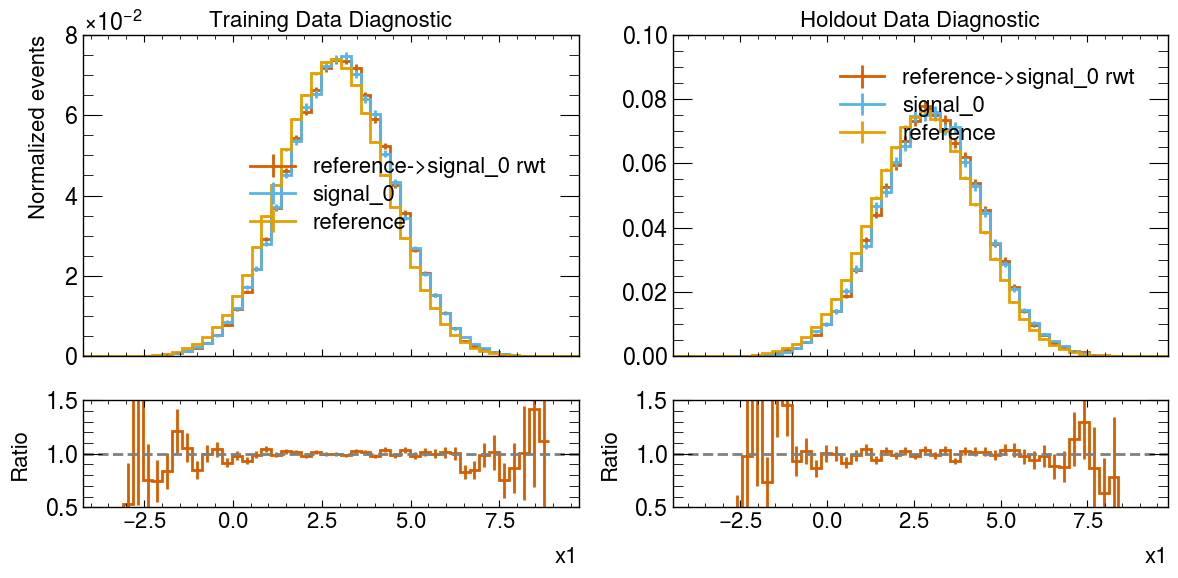

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:320: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hi

<Figure size 800x600 with 0 Axes>

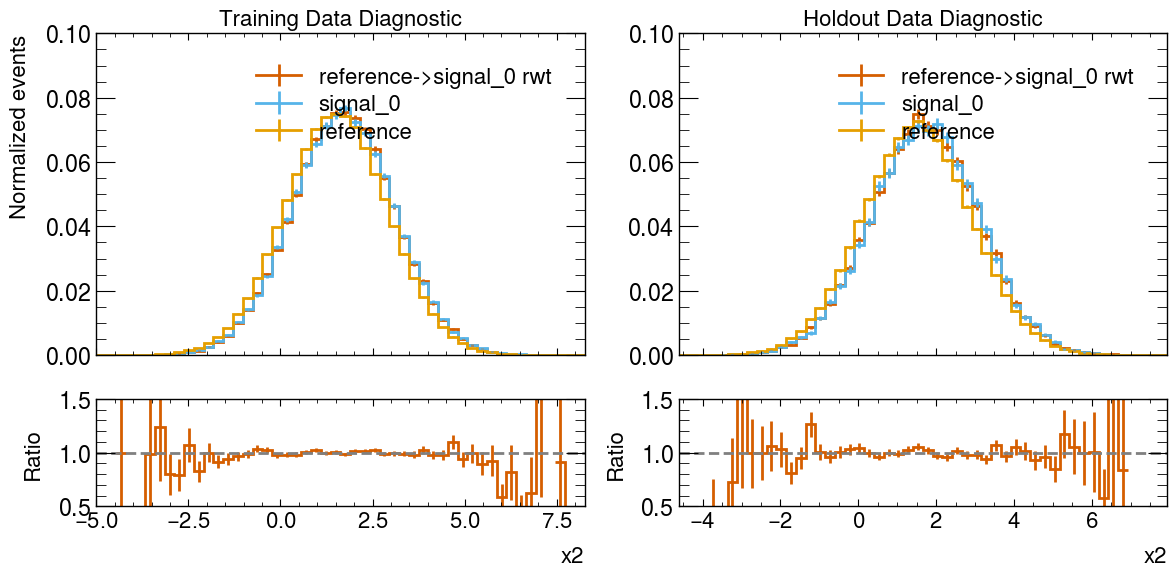

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:320: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hi

<Figure size 800x600 with 0 Axes>

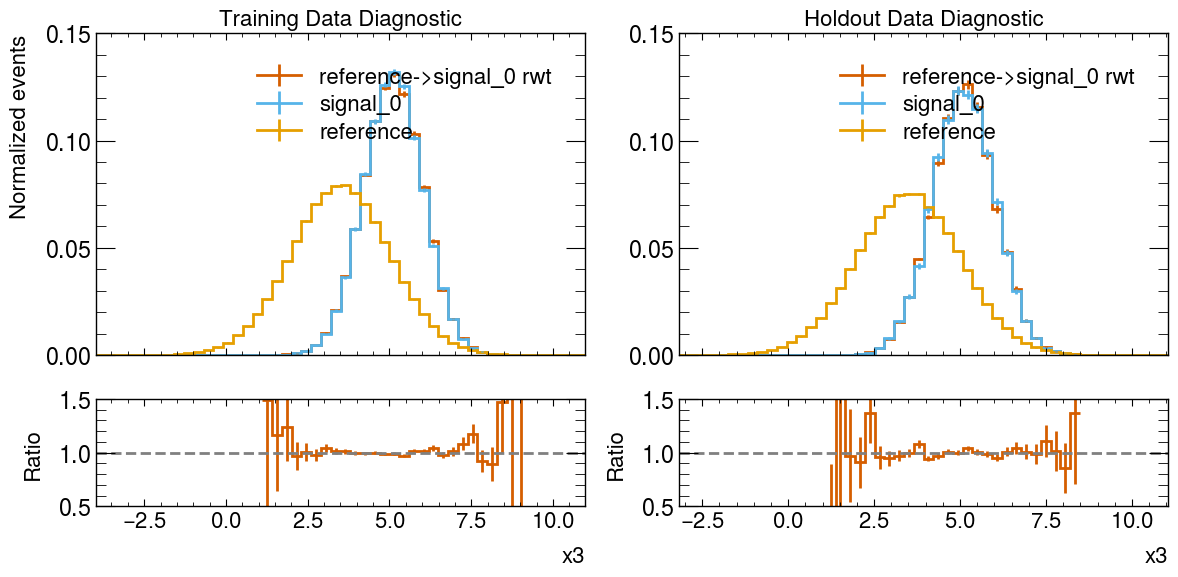

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:320: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hi

<Figure size 800x600 with 0 Axes>

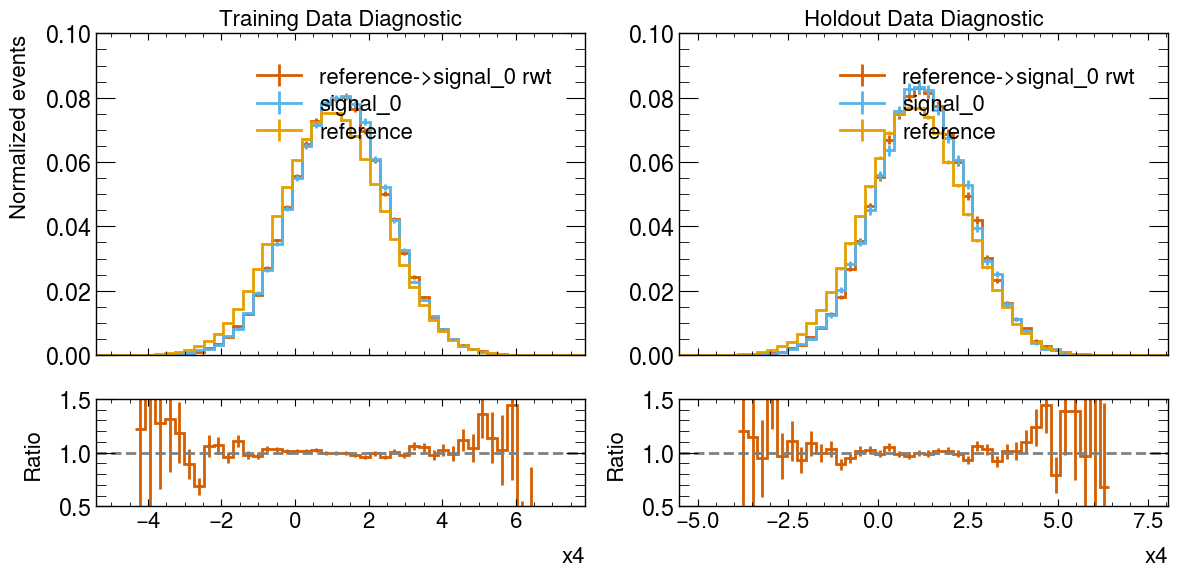

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:320: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


<Figure size 800x600 with 0 Axes>

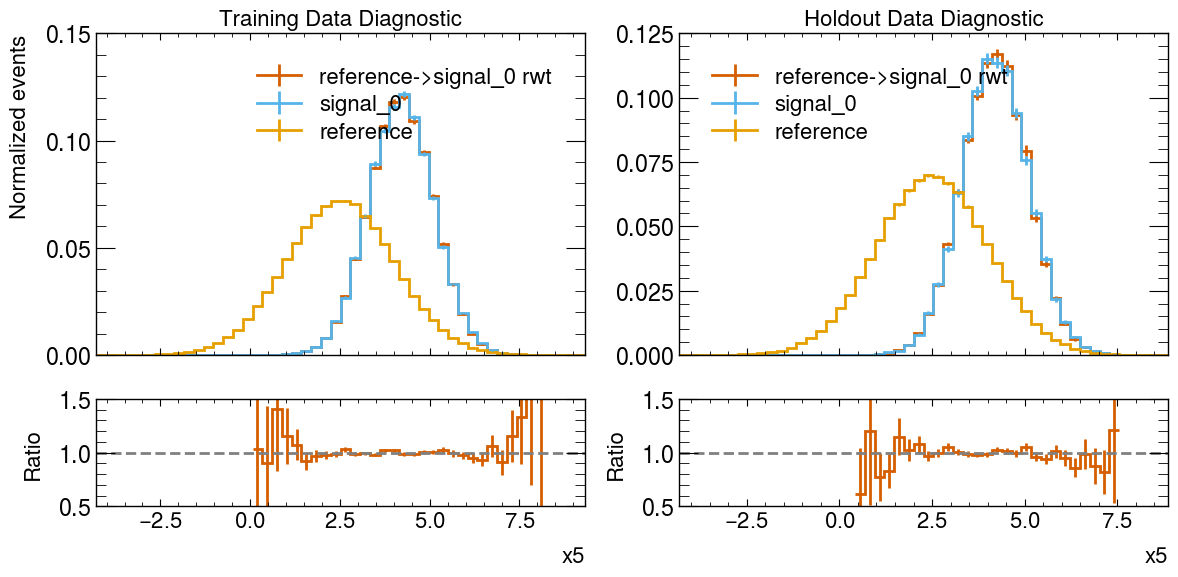

<Figure size 800x600 with 0 Axes>

In [13]:
trainer.make_reweighted_plots(training_features, "linear", 50)